# C09 Final reseed comparison

Aggregate the top-3 reseed runs, compare stability, and produce a final recommendation table for the thesis.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None


In [2]:
CWD = Path.cwd()
NOTEBOOKS_DIR = CWD.parent if CWD.name == "challengers" else CWD
PROJECT_ROOT = NOTEBOOKS_DIR.parent
FIGURES_DIR = PROJECT_ROOT / "figures" / "challengers"
MODELS_DIR = PROJECT_ROOT / "notebooks" / "models" / "challengers"

RUNS_CSV = FIGURES_DIR / "c08_top3_reseed_runs.csv"
FINAL_TABLE_CSV = FIGURES_DIR / "c09_final_reseed_comparison.csv"
FINAL_DECISION_JSON = FIGURES_DIR / "c09_final_model_recommendation.json"
FINAL_PLOT = FIGURES_DIR / "c09_reseed_tradeoff_scatter.png"

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"RUNS_CSV exists: {RUNS_CSV.exists()}")


PROJECT_ROOT: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository
RUNS_CSV exists: True


In [3]:
def _safe_float(value):
    if value is None:
        return np.nan
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan


if RUNS_CSV.exists():
    runs_df = pd.read_csv(RUNS_CSV)
else:
    rows = []
    for config_path in sorted(MODELS_DIR.glob("*_seed*/training_config.json")):
        config = json.loads(config_path.read_text())
        rows.append({
            "model_name": config_path.parent.name,
            "base_model_name": config.get("base_model_name"),
            "method": config.get("method"),
            "recipe": config.get("recipe"),
            "seed": config.get("seed"),
            "epochs": config.get("epochs"),
            "accuracy": _safe_float(config.get("accuracy")),
            "macro_f1": _safe_float(config.get("macro_f1")),
            "worst_gap": _safe_float(config.get("tpr_gap_worst_robust")),
            "macro_gap": _safe_float(config.get("tpr_gap_macro_robust")),
            "model_dir": str(config_path.parent.relative_to(PROJECT_ROOT)),
        })
    runs_df = pd.DataFrame(rows)

if runs_df.empty:
    raise FileNotFoundError("No reseed runs found. Run c08_top3_reseed.ipynb first.")

runs_df = runs_df.sort_values(["base_model_name", "seed"]).reset_index(drop=True)
runs_df


,model_name,base_model_name,method,recipe,seed,epochs,accuracy,macro_f1,worst_gap,macro_gap,model_dir
0,label_smoothing_eps01_2ep_seed7,label_smoothing_eps01_2ep,Label Smoothing + sqrt_rw,label_smoothing,7,2,0.598185,0.608785,0.358824,0.129374,notebooks/models/challengers/label_smoothing_e...
1,label_smoothing_eps01_2ep_seed13,label_smoothing_eps01_2ep,Label Smoothing + sqrt_rw,label_smoothing,13,2,0.586025,0.604257,0.305882,0.133726,notebooks/models/challengers/label_smoothing_e...
2,label_smoothing_eps01_2ep_seed21,label_smoothing_eps01_2ep,Label Smoothing + sqrt_rw,label_smoothing,21,2,0.599819,0.616264,0.270588,0.120324,notebooks/models/challengers/label_smoothing_e...
3,rdrop_alpha10_2ep_seed7,rdrop_alpha10_2ep,R-Drop + sqrt_rw,rdrop,7,2,0.585299,0.611890,0.335294,0.109263,notebooks/models/challengers/rdrop_alpha10_2ep...
4,rdrop_alpha10_2ep_seed13,rdrop_alpha10_2ep,R-Drop + sqrt_rw,rdrop,13,2,0.608348,0.619940,0.317647,0.140056,notebooks/models/challengers/rdrop_alpha10_2ep...
5,rdrop_alpha10_2ep_seed21,rdrop_alpha10_2ep,R-Drop + sqrt_rw,rdrop,21,2,0.603267,0.620292,0.335294,0.138644,notebooks/models/challengers/rdrop_alpha10_2ep...
6,weighted_sampler_citypow15_2ep_seed7,weighted_sampler_citypow15_2ep,Weighted Sampler (city_group) + Plain CE,weighted_sampler,7,2,0.568603,0.568808,0.376471,0.131581,notebooks/models/challengers/weighted_sampler_...
7,weighted_sampler_citypow15_2ep_seed13,weighted_sampler_citypow15_2ep,Weighted Sampler (city_group) + Plain CE,weighted_sampler,13,2,0.568784,0.569111,0.300000,0.123238,notebooks/models/challengers/weighted_sampler_...
8,weighted_sampler_citypow15_2ep_seed21,weighted_sampler_citypow15_2ep,Weighted Sampler (city_group) + Plain CE,weighted_sampler,21,2,0.564065,0.560726,0.288235,0.125279,notebooks/models/challengers/weighted_sampler_...


In [4]:
agg_df = runs_df.groupby(["base_model_name", "method", "recipe"], dropna=False).agg(
    runs=("seed", "count"),
    seeds=("seed", lambda s: ",".join(str(int(x)) for x in sorted(s))),
    accuracy_mean=("accuracy", "mean"),
    accuracy_std=("accuracy", "std"),
    macro_f1_mean=("macro_f1", "mean"),
    macro_f1_std=("macro_f1", "std"),
    worst_gap_mean=("worst_gap", "mean"),
    worst_gap_std=("worst_gap", "std"),
    macro_gap_mean=("macro_gap", "mean"),
    macro_gap_std=("macro_gap", "std"),
).reset_index()

agg_df = agg_df.sort_values(["macro_f1_mean", "worst_gap_mean"], ascending=[False, True]).reset_index(drop=True)
agg_df.insert(0, "final_rank", np.arange(1, len(agg_df) + 1))
agg_df


,final_rank,base_model_name,method,recipe,runs,seeds,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,worst_gap_mean,worst_gap_std,macro_gap_mean,macro_gap_std
0,1,rdrop_alpha10_2ep,R-Drop + sqrt_rw,rdrop,3,"7,13,21",0.598972,0.012110,0.617374,0.004753,0.329412,0.010189,0.129321,0.017385
1,2,label_smoothing_eps01_2ep,Label Smoothing + sqrt_rw,label_smoothing,3,"7,13,21",0.594676,0.007536,0.609768,0.006064,0.311765,0.044411,0.127808,0.006837
2,3,weighted_sampler_citypow15_2ep,Weighted Sampler (city_group) + Plain CE,weighted_sampler,3,"7,13,21",0.567151,0.002673,0.566215,0.004756,0.321569,0.047909,0.126699,0.004349


In [5]:
leader = agg_df.iloc[0].to_dict()
decision = {
    "recommended_model": leader["base_model_name"],
    "method": leader["method"],
    "runs": int(leader["runs"]),
    "seeds": leader["seeds"],
    "macro_f1_mean": float(leader["macro_f1_mean"]),
    "macro_f1_std": float(leader["macro_f1_std"]) if pd.notna(leader["macro_f1_std"]) else None,
    "worst_gap_mean": float(leader["worst_gap_mean"]),
    "macro_gap_mean": float(leader["macro_gap_mean"]),
}

agg_df.to_csv(FINAL_TABLE_CSV, index=False)
FINAL_DECISION_JSON.write_text(json.dumps(decision, indent=2))

print(f"Saved final table to: {FINAL_TABLE_CSV}")
print(f"Saved final decision to: {FINAL_DECISION_JSON}")
agg_df


Saved final table to: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/figures/challengers/c09_final_reseed_comparison.csv
Saved final decision to: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/figures/challengers/c09_final_model_recommendation.json


,final_rank,base_model_name,method,recipe,runs,seeds,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,worst_gap_mean,worst_gap_std,macro_gap_mean,macro_gap_std
0,1,rdrop_alpha10_2ep,R-Drop + sqrt_rw,rdrop,3,"7,13,21",0.598972,0.012110,0.617374,0.004753,0.329412,0.010189,0.129321,0.017385
1,2,label_smoothing_eps01_2ep,Label Smoothing + sqrt_rw,label_smoothing,3,"7,13,21",0.594676,0.007536,0.609768,0.006064,0.311765,0.044411,0.127808,0.006837
2,3,weighted_sampler_citypow15_2ep,Weighted Sampler (city_group) + Plain CE,weighted_sampler,3,"7,13,21",0.567151,0.002673,0.566215,0.004756,0.321569,0.047909,0.126699,0.004349


In [6]:
display_cols = [
    "final_rank",
    "base_model_name",
    "method",
    "runs",
    "seeds",
    "accuracy_mean",
    "accuracy_std",
    "macro_f1_mean",
    "macro_f1_std",
    "worst_gap_mean",
    "macro_gap_mean",
]
agg_df[display_cols]


,final_rank,base_model_name,method,runs,seeds,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,worst_gap_mean,macro_gap_mean
0,1,rdrop_alpha10_2ep,R-Drop + sqrt_rw,3,"7,13,21",0.598972,0.012110,0.617374,0.004753,0.329412,0.129321
1,2,label_smoothing_eps01_2ep,Label Smoothing + sqrt_rw,3,"7,13,21",0.594676,0.007536,0.609768,0.006064,0.311765,0.127808
2,3,weighted_sampler_citypow15_2ep,Weighted Sampler (city_group) + Plain CE,3,"7,13,21",0.567151,0.002673,0.566215,0.004756,0.321569,0.126699


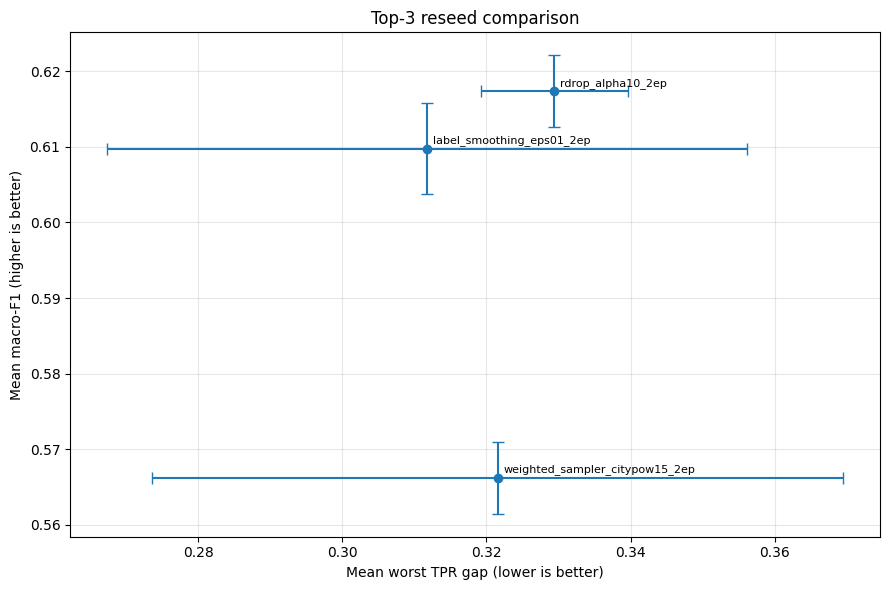

Saved plot to: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/figures/challengers/c09_reseed_tradeoff_scatter.png


In [7]:
if plt is None:
    print("matplotlib is not installed; skipping plots")
else:
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.errorbar(
        agg_df["worst_gap_mean"],
        agg_df["macro_f1_mean"],
        xerr=agg_df["worst_gap_std"].fillna(0.0),
        yerr=agg_df["macro_f1_std"].fillna(0.0),
        fmt="o",
        capsize=4,
    )
    for _, row in agg_df.iterrows():
        ax.annotate(row["base_model_name"], (row["worst_gap_mean"], row["macro_f1_mean"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
    ax.set_xlabel("Mean worst TPR gap (lower is better)")
    ax.set_ylabel("Mean macro-F1 (higher is better)")
    ax.set_title("Top-3 reseed comparison")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FINAL_PLOT, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved plot to: {FINAL_PLOT}")


In [8]:
print("Recommended final model:")
print(json.dumps(decision, indent=2))


Recommended final model:
{
  "recommended_model": "rdrop_alpha10_2ep",
  "method": "R-Drop + sqrt_rw",
  "runs": 3,
  "seeds": "7,13,21",
  "macro_f1_mean": 0.6173737709183578,
  "macro_f1_std": 0.004752660432165787,
  "worst_gap_mean": 0.32941176470588235,
  "macro_gap_mean": 0.1293208451443175
}
